## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [65]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [66]:
def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

In [67]:
def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)

In [68]:
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


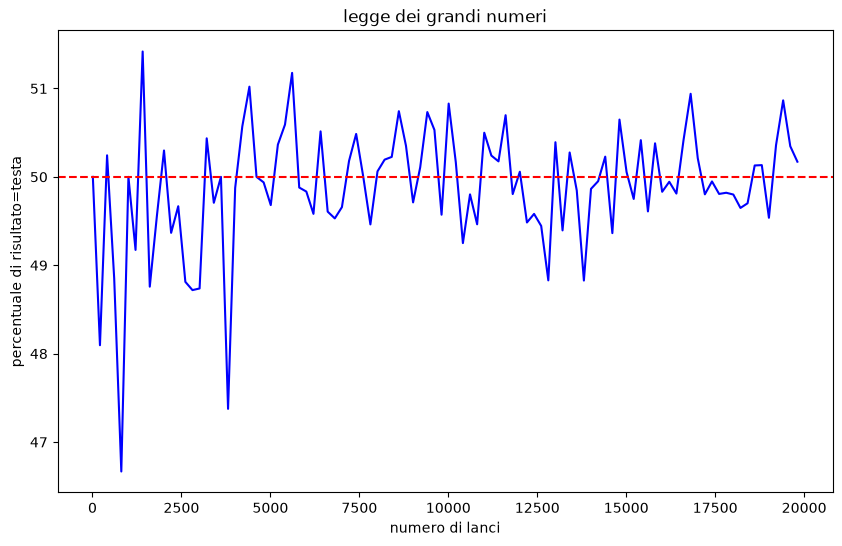

In [69]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [70]:
# 📦 Caricamento del dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [71]:
print(df.shape) #ci sono 891 righe e 12 colonne

#valori mancanti
mancanti = len(df) - df.count()#totale meno i non nulli
print(mancanti)

#si poteva anche fare con:
df.isnull().sum()


#sostituzione dei valori mancanti in embarked
print(df['Embarked'].value_counts())

moda = df['Embarked'].mode()[0] # la modo è il valore piu frequente
print('moda: ', moda)

df['Embarked'] = np.where(df['Embarked'].notna(), df['Embarked'], moda)
print('mancanti dopo:', len(df) - df['Embarked'].count()) #fatto questo per verficare che abbia funzionato la sostituzione

#potevo anche fare:
df['Embarked']= df['Embarked'].fillna(moda)


#verifica linee duplicate (basta vedere se ci sono delle persone con lo stesso nome)
df.duplicated().sum()


#eta media dei passeggeri per ogni classe
medie = df.groupby('Pclass')['Age'].mean()
print('medie: ',medie)

media_Age = df['Age'].mean()


#sostituisco i valori mancanti di age con la media
df['Age'] = df['Age'].fillna(media_Age)

(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
moda:  S
mancanti dopo: 0
medie:  Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


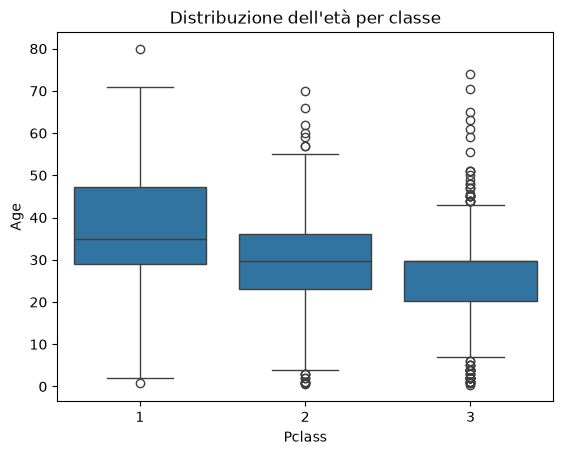

In [72]:
#distribuzioni dell' età per classe 
sns.boxplot(data=df, x='Pclass', y='Age')
plt.title("Distribuzione dell'età per classe")
plt.show()

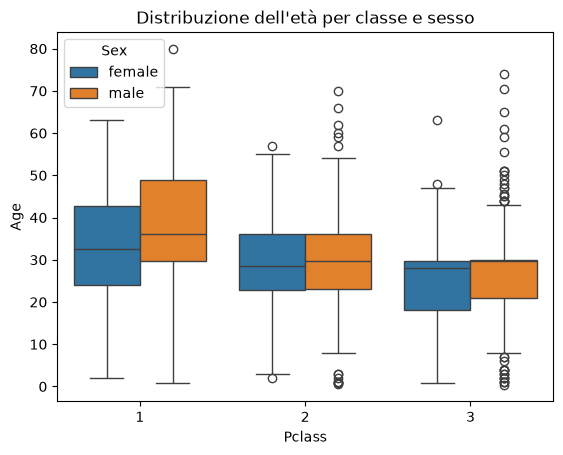

In [73]:
#Distribuzione dell'età per classe e sesso
sns.boxplot(data=df, x='Pclass', y='Age', hue='Sex')
plt.title("Distribuzione dell'età per classe e sesso")
plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [75]:
df.info()
df.describe()


#distribuzione delle specie
df['species'].value_counts()

#oppure potevo fare:
df.groupby('species').size()


#lunghezza e larghezza media dei petali
lunghezza_media = df['sepal_length'].mean()
print('lunghezza media: ', lunghezza_media)

larghezza_media = df['sepal_width'].mean()
print('larghezza media: ', larghezza_media)


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB
lunghezza media:  5.843333333333334
larghezza media:  3.0573333333333337


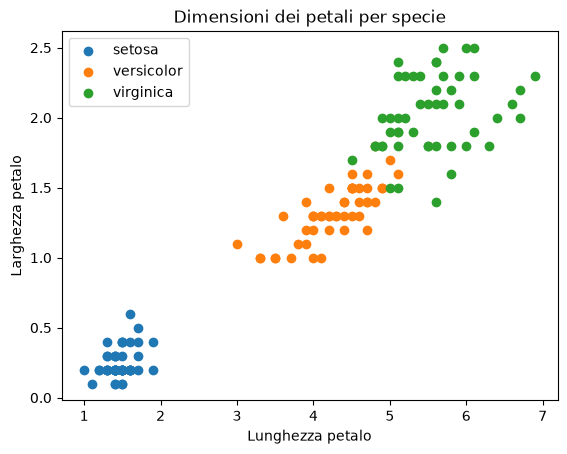

In [76]:
#scatterplot delle dimensioni dei petali per specie
for specie in df['species'].unique():
    gruppo = df[df['species'] == specie]
    plt.scatter(gruppo['petal_length'], gruppo['petal_width'], label=specie)


plt.title('Dimensioni dei petali per specie')
plt.xlabel('Lunghezza petalo')
plt.ylabel('Larghezza petalo')
plt.legend()
plt.show()

In [77]:
#nuova colonna per l area del petalo
df['petal_area'] = df['petal_width']*df['petal_length']
#è un area approssimativa perchè le foglie non sono rettangolari

df.head()

df['petal_area'].describe()

count    150.000000
mean       5.794067
std        4.712390
min        0.110000
25%        0.420000
50%        5.615000
75%        9.690000
max       15.870000
Name: petal_area, dtype: float64

c'è un enorme dispersione, lo notiamo per il fatto che la deviazione standard è molto vicino alla media.
inoltre il primo quartile è lontanissimo dalla mediana

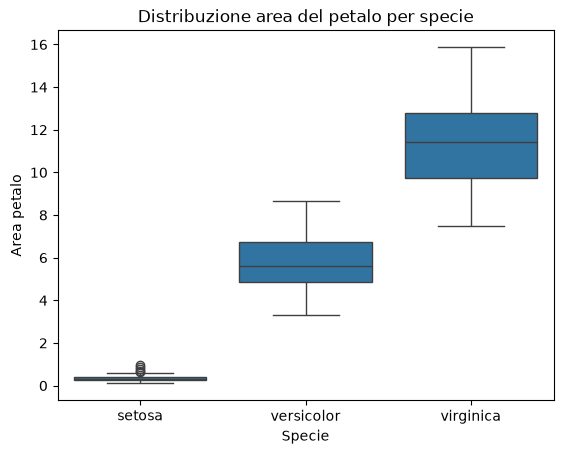

In [78]:
#grafico della distribuzione dell area del petalo per specie
sns.boxplot(data=df, x='species', y='petal_area')
plt.title('Distribuzione area del petalo per specie')
plt.xlabel('Specie')
plt.ylabel('Area petalo')
plt.show()